### 10. (a) Implement a simple GAN to generate handwritten digits (MNIST). 

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data loader
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])
dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

In [9]:
# Generator
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(100, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 28*28),
            nn.Tanh()
        )
    def forward(self, x):
        x = self.model(x)
        return x.view(-1, 1, 28, 28)

# Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.model(x)

In [10]:
# Initialize models
generator = Generator().to(device)
discriminator = Discriminator().to(device)

# Loss and optimizers
criterion = nn.BCELoss()
optim_G = optim.Adam(generator.parameters(), lr=0.0002)
optim_D = optim.Adam(discriminator.parameters(), lr=0.0002)

# Training loop
epochs = 20
for epoch in range(epochs):
    for real_imgs, _ in dataloader:
        real_imgs = real_imgs.to(device)
        batch_size = real_imgs.size(0)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # Train Discriminator
        z = torch.randn(batch_size, 100).to(device)
        fake_imgs = generator(z)

        real_loss = criterion(discriminator(real_imgs), real_labels)
        fake_loss = criterion(discriminator(fake_imgs.detach()), fake_labels)
        d_loss = real_loss + fake_loss

        optim_D.zero_grad()
        d_loss.backward()
        optim_D.step()

        # Train Generator
        z = torch.randn(batch_size, 100).to(device)
        fake_imgs = generator(z)
        g_loss = criterion(discriminator(fake_imgs), real_labels)

        optim_G.zero_grad()
        g_loss.backward()
        optim_G.step()

    print(f"Epoch {epoch+1}/{epochs} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

Epoch 1/20 | D Loss: 0.0476 | G Loss: 4.3361
Epoch 2/20 | D Loss: 1.0883 | G Loss: 5.2691
Epoch 3/20 | D Loss: 0.3729 | G Loss: 7.9164
Epoch 4/20 | D Loss: 0.0132 | G Loss: 5.1437
Epoch 5/20 | D Loss: 0.0004 | G Loss: 7.9253
Epoch 6/20 | D Loss: 0.0003 | G Loss: 8.7808
Epoch 7/20 | D Loss: 0.0001 | G Loss: 10.1741
Epoch 8/20 | D Loss: 0.0001 | G Loss: 10.4866
Epoch 9/20 | D Loss: 0.0000 | G Loss: 10.9440
Epoch 10/20 | D Loss: 0.0001 | G Loss: 11.2919
Epoch 11/20 | D Loss: 0.0000 | G Loss: 11.2371
Epoch 12/20 | D Loss: 0.0001 | G Loss: 9.5475
Epoch 13/20 | D Loss: 0.0012 | G Loss: 8.2034
Epoch 14/20 | D Loss: 0.0002 | G Loss: 9.7456
Epoch 15/20 | D Loss: 0.0001 | G Loss: 10.3250
Epoch 16/20 | D Loss: 0.0000 | G Loss: 11.8137
Epoch 17/20 | D Loss: 0.0000 | G Loss: 12.3804
Epoch 18/20 | D Loss: 0.0000 | G Loss: 12.8943
Epoch 19/20 | D Loss: 0.0000 | G Loss: 13.3291
Epoch 20/20 | D Loss: 0.0000 | G Loss: 13.7595


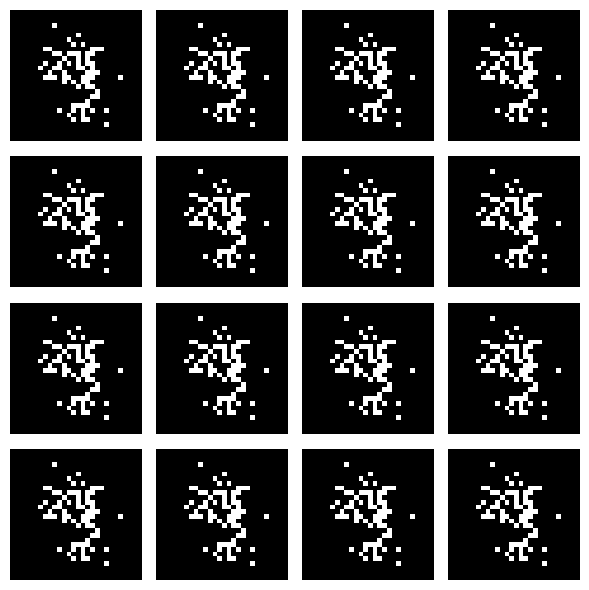

In [13]:
# Visualize generated images
generator.eval()
z = torch.randn(16, 100).to(device)
with torch.no_grad():
    generated = generator(z).cpu()

fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(generated[i].squeeze(), cmap='gray')
    ax.axis('off')
plt.tight_layout()
plt.show()